# Notebook 02 — TF-IDF + Logistic Regression baseline

**Input:** same train/val split from notebook 00  
**Output:** `model/artifacts/baseline.pkl`

Simple bag-of-words baseline to compare against PhoBERT in notebook 03.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyvi.ViTokenizer import tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
elif not (PROJECT_ROOT / "model" / "config.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from model.config import BASELINE_PKL_PATH, LABELED_CSV_PATH, SPLIT_INDICES_PATH

LABELS = ["negative", "neutral", "positive"]
sns.set_theme(style="whitegrid")
print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/pdc/PycharmProjects/matgrouptest


## 1. Load same split as notebook 01

Uses `split_indices.json` so both models see identical train/val rows.

In [2]:
with SPLIT_INDICES_PATH.open(encoding="utf-8") as f:
    split = json.load(f)

df = pd.read_csv(LABELED_CSV_PATH)
train_df = df.loc[split["train_indices"]].reset_index(drop=True)
val_df = df.loc[split["val_indices"]].reset_index(drop=True)

print(f"Train: {len(train_df)}  Val: {len(val_df)}")
print(train_df["sentiment"].value_counts())

Train: 799  Val: 200
sentiment
neutral     420
negative    197
positive    182
Name: count, dtype: int64


## 2. Preprocess

`pyvi` word segmentation + lowercase. Diacritics kept (baseline handles no-diacritics text better than PhoBERT).

In [3]:
def preprocess(text: str) -> str:
    return tokenize(" ".join(str(text).split())).lower()


train_df = train_df.copy()
val_df = val_df.copy()
train_df["text"] = train_df["comment"].map(preprocess)
val_df["text"] = val_df["comment"].map(preprocess)

print("Sample:", train_df["text"].iloc[0][:120])

Sample: xe này rất đẹp


## 3. Train pipeline

`TfidfVectorizer` (1–2 grams, 10k features) → `LogisticRegression`.

In [4]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=10_000)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

pipeline.fit(train_df["text"], train_df["sentiment"])
print("Trained.")

Trained.


## 4. Evaluate on validation set

Same metrics as notebook 01: accuracy, macro-F1, per-class report, confusion matrix.

Accuracy:  0.615
Macro-F1:  0.453
Weighted-F1: 0.534

              precision    recall  f1-score   support

    negative       0.78      0.14      0.24        50
     neutral       0.59      1.00      0.74       105
    positive       0.85      0.24      0.38        45

    accuracy                           0.61       200
   macro avg       0.74      0.46      0.45       200
weighted avg       0.69      0.61      0.53       200



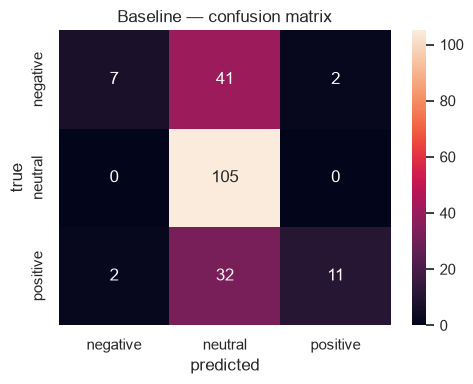

In [5]:
y_true = val_df["sentiment"]
y_pred = pipeline.predict(val_df["text"])

print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
print(f"Macro-F1:  {f1_score(y_true, y_pred, average='macro'):.3f}")
print(f"Weighted-F1: {f1_score(y_true, y_pred, average='weighted'):.3f}")
print()
print(classification_report(y_true, y_pred, target_names=LABELS))

cm = confusion_matrix(y_true, y_pred, labels=LABELS)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("Baseline — confusion matrix")
plt.tight_layout()
plt.show()

## 5. Sample predictions (5 correct + 5 wrong)

In [6]:
results = val_df.copy()
results["pred"] = y_pred
results["correct"] = results["sentiment"] == results["pred"]

print("=== 5 correct ===")
display(results.loc[results["correct"], ["comment", "sentiment", "pred"]].head(5))

print("=== 5 wrong ===")
display(results.loc[~results["correct"], ["comment", "sentiment", "pred"]].head(5))

=== 5 correct ===


,comment,sentiment,pred
1,​ Bác ở chung cư à😂. Ở nhà đất có gara thì sạ...,neutral,neutral
2,"nhanh thế, full đen đẹp quá nhỉ, xúc",positive,positive
4,"Mình rất thích nội thất màu nâu, ghi, kem",positive,positive
5,Cái này đúng phải gọi là phiên bản 7.5 All New...,neutral,neutral
6,Nc lớn còn chưa cấm nổi thì vn mình xe xăng cò...,neutral,neutral


=== 5 wrong ===


,comment,sentiment,pred
0,khách mời vui tính dễ thương quá.,positive,neutral
3,Tipcar ko lòng vòng vào vấn đề nhanh gọn công tâm,positive,neutral
8,Tôi đang đi Lexus 470 hơn 10 đăng ký Vf9 ngày ...,positive,neutral
13,Những con nhạt nhẽo thường sẽ bán chạy,negative,neutral
20,Cảm ơn bác đã ủng hộ nhé!,positive,neutral


## 6. Export

Saved as joblib pipeline for notebook 03.

In [7]:
BASELINE_PKL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(pipeline, BASELINE_PKL_PATH)
print(f"Saved: {BASELINE_PKL_PATH}")

Saved: /Users/pdc/PycharmProjects/matgrouptest/model/artifacts/baseline.pkl
